In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math

In [ ]:
from pandas.core.reshape import encoding
df = pd.read_csv('imigrantes_canada.csv', delimiter = ',', encoding='utf8')

In [ ]:
df.set_index('País', inplace=True)
df.head()

,Continente,Região,1980,1981,1982,1983,1984,1985,1986,1987,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
País,,,,,,,,,,,,,,,,,,,,,
Afeganistão,Ásia,Sul da Ásia,16,39,39,47,71,340,496,741,...,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
Albânia,Europa,Sul da Europa,1,0,0,0,0,0,1,2,...,1223,856,702,560,716,561,539,620,603,15699
Argélia,África,Norte da África,80,67,71,69,63,44,69,132,...,3626,4807,3623,4005,5393,4752,4325,3774,4331,69439
Samoa Americana,Oceânia,Polinésia,0,1,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,6
Andorra,Europa,Sul da Europa,0,0,0,0,0,0,2,0,...,0,1,1,0,0,0,0,1,1,15


In [ ]:
anos = list(map(str, range(1980, 2013)))
anos

['1980',
 '1981',
 '1982',
 '1983',
 '1984',
 '1985',
 '1986',
 '1987',
 '1988',
 '1989',
 '1990',
 '1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012']

In [ ]:
brasil = df.loc['Brasil', anos]
brasil


,Brasil
1980,211
1981,220
1982,192
1983,139
1984,145
1985,130
1986,205
1987,244
1988,394
1989,650


In [ ]:
brasil_dict = {'ano': brasil.index.tolist(),
               'imigrantes' : brasil.values.tolist()}
dados_brasil = pd.DataFrame(brasil_dict)
dados_brasil

,ano,imigrantes
0,1980,211
1,1981,220
2,1982,192
3,1983,139
4,1984,145
5,1985,130
6,1986,205
7,1987,244
8,1988,394
9,1989,650


Alternativa, com MELT

In [ ]:
from pandas.core.reshape import encoding
df2 = pd.read_csv('imigrantes_canada.csv', delimiter = ',', encoding='utf8')

df_teste = pd.melt(df2, id_vars='País', value_vars=anos)
df_teste = df_teste.loc[df_teste['País'] == 'Brasil']
df_teste.pop('País')
df_teste.columns = ['Ano', 'Imigrantes']
df_teste.reset_index(drop=True, inplace=True)
df_teste

,Ano,Imigrantes
0,1980,211
1,1981,220
2,1982,192
3,1983,139
4,1984,145
5,1985,130
6,1986,205
7,1987,244
8,1988,394
9,1989,650


MATPLOTLYB - PLT

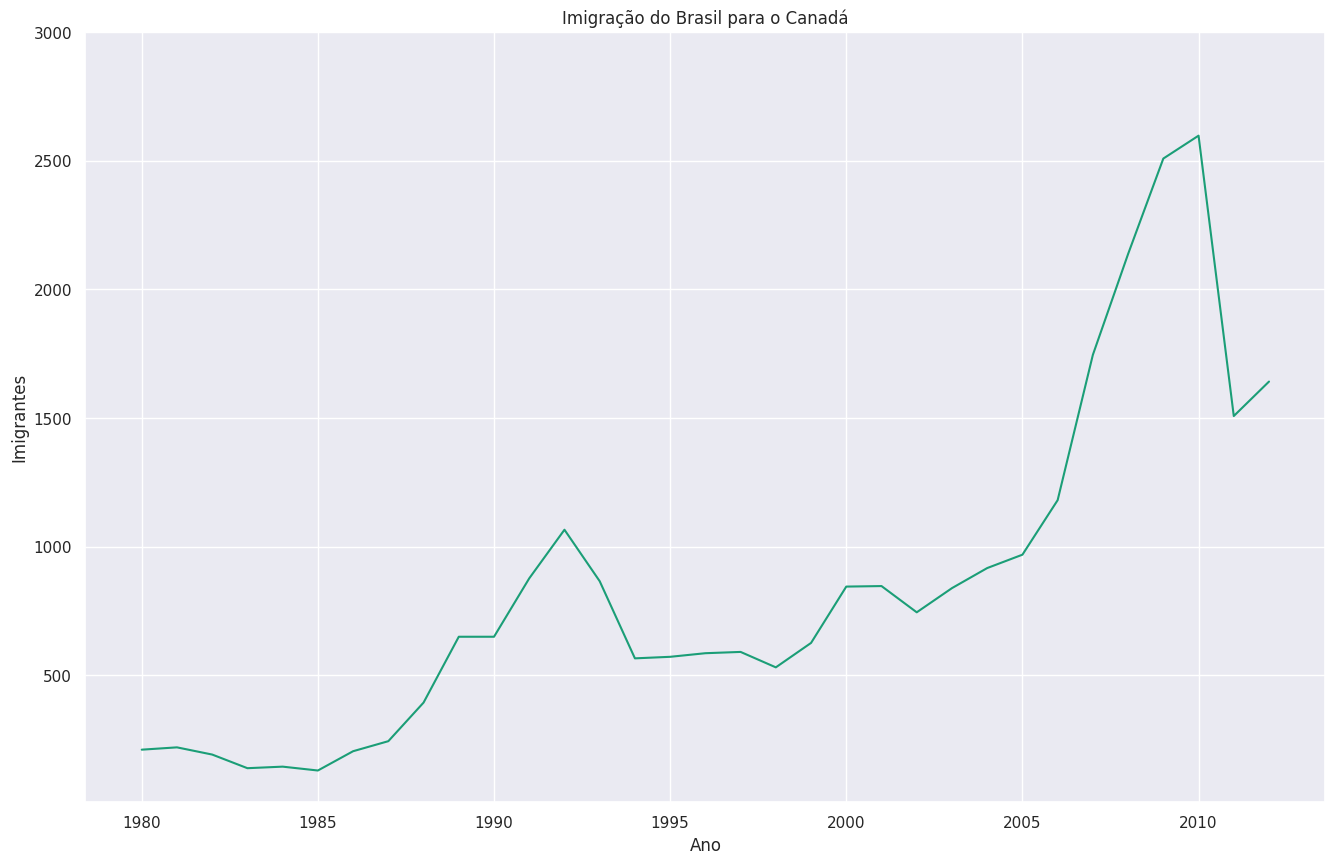

In [ ]:
plt.figure(figsize=(16,10))

plt.plot(dados_brasil['ano'], dados_brasil['imigrantes'])
plt.title('Imigração do Brasil para o Canadá')
plt.xlabel('Ano')
plt.ylabel('Imigrantes')

plt.xticks(['1980', '1985', '1990', '1995', '2000', '2005', '2010'])
plt.yticks([500, 1000, 1500, 2000, 2500, 3000])

plt.show()

Teste

In [ ]:
df2 = pd.read_csv('imigrantes_canada.csv', delimiter = ',', encoding='utf8')
brasil_argentina = pd.melt(df2, id_vars=['País'], value_vars=anos)
brasil_argentina = brasil_argentina.loc[(brasil_argentina['País'] == 'Brasil') | (brasil_argentina['País'] == 'Argentina')]
brasil_argentina.columns = ['País', 'Ano', 'Imigrantes']
brasil_argentina.set_index('País', inplace=True)
brasil_argentina

,Ano,Imigrantes
País,,
Argentina,1980,368
Brasil,1980,211
Argentina,1981,426
Brasil,1981,220
Argentina,1982,626
...,...,...
Brasil,2010,2598
Argentina,2011,278
Brasil,2011,1508


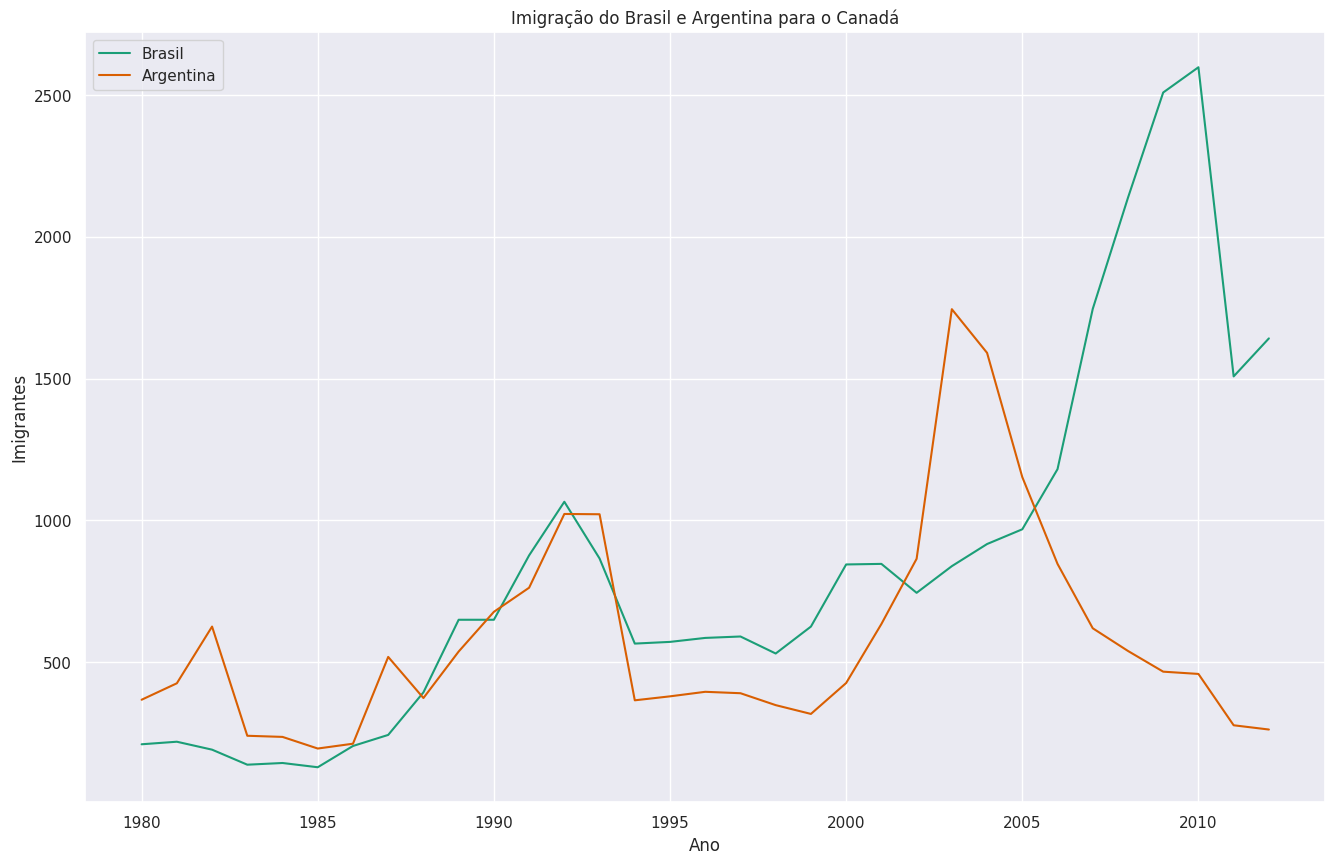

In [ ]:
plt.figure(figsize=(16,10))

plt.plot(brasil_argentina.loc['Brasil']['Ano'], brasil_argentina.loc['Brasil']['Imigrantes'], label='Brasil')
plt.plot(brasil_argentina.loc['Argentina']['Ano'], brasil_argentina.loc['Argentina']['Imigrantes'], label='Argentina')

plt.title('Imigração do Brasil e Argentina para o Canadá')
plt.xlabel('Ano')
plt.ylabel('Imigrantes')
plt.xticks(['1980', '1985', '1990', '1995', '2000', '2005', '2010'])
plt.legend()
plt.show()

Voltando ao material

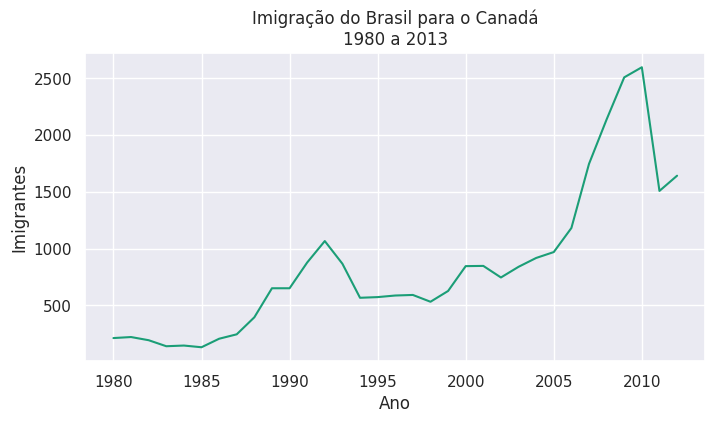

In [ ]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(dados_brasil['ano'], dados_brasil['imigrantes'])
ax.set_title('Imigração do Brasil para o Canadá\n1980 a 2013')
ax.set_xlabel('Ano')
ax.set_ylabel('Imigrantes')
ax.xaxis.set_major_locator(plt.MultipleLocator(5))
plt.show()

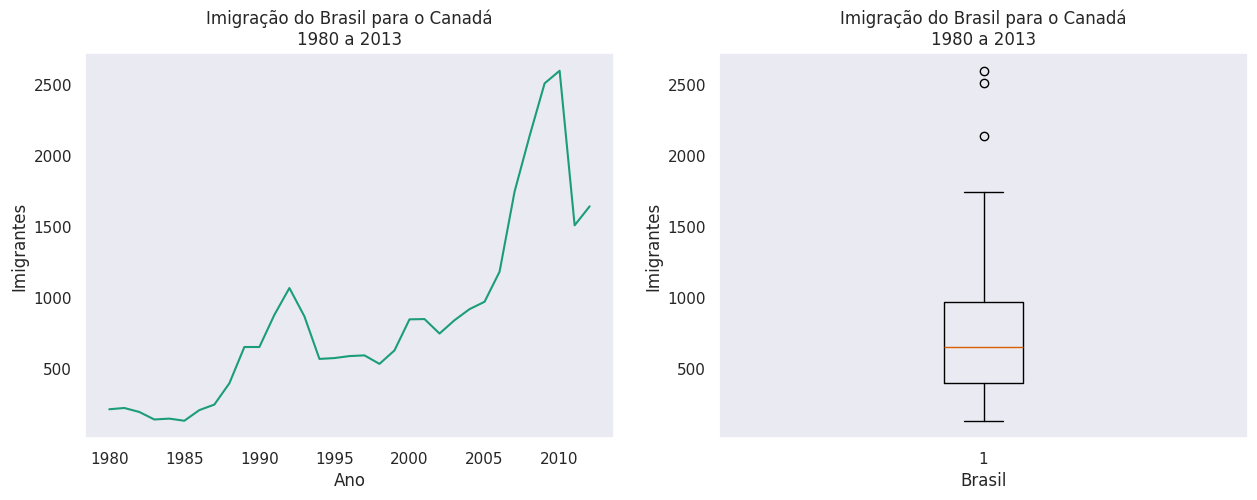

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15,5))
axs[0].plot(dados_brasil['ano'], dados_brasil['imigrantes'])
axs[0].set_title('Imigração do Brasil para o Canadá\n1980 a 2013')
axs[0].set_xlabel('Ano')
axs[0].set_ylabel('Imigrantes')
axs[0].xaxis.set_major_locator(plt.MultipleLocator(5))
axs[0].grid()

axs[1].boxplot(dados_brasil['imigrantes'])
axs[1].set_title('Imigração do Brasil para o Canadá\n1980 a 2013')
axs[1].set_xlabel('Brasil')
axs[1].set_ylabel('Imigrantes')
axs[1].grid()

plt.show()

In [ ]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


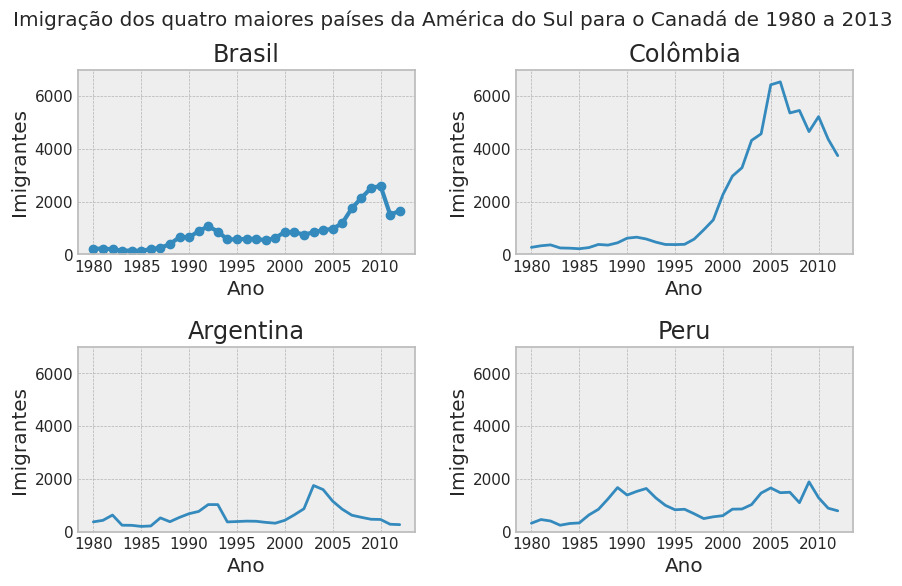

In [ ]:
with plt.style.context('bmh'):
  fig, axs = plt.subplots(2,2, figsize=(10,6))
  fig.subplots_adjust(hspace=0.5, wspace=0.3)
  fig.suptitle('Imigração dos quatro maiores países da América do Sul para o Canadá de 1980 a 2013')

  axs[0,0].plot(df.loc['Brasil', anos], lw=3, marker='o')
  axs[0,0].set_title('Brasil')

  axs[0,1].plot(df.loc['Colômbia', anos])
  axs[0,1].set_title('Colômbia')

  axs[1,0].plot(df.loc['Argentina', anos])
  axs[1,0].set_title('Argentina')

  axs[1,1].plot(df.loc['Peru', anos])
  axs[1,1].set_title('Peru')

  for ax in axs.flat:
      ax.xaxis.set_major_locator(plt.MultipleLocator(5))

  for ax in axs.flat:
      ax.set_xlabel('Ano')
      ax.set_ylabel('Imigrantes')

  ymin = 0
  ymax = 7000

  for ax in axs.ravel():
    ax.set_ylim(ymin, ymax)

  plt.show()

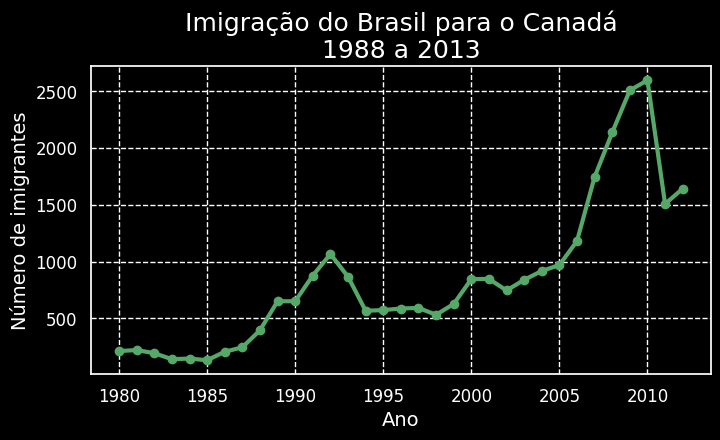

In [ ]:
with plt.style.context('dark_background'):
  fig, ax = plt.subplots(figsize=(8,4))
  ax.plot(dados_brasil['ano'], dados_brasil['imigrantes'], lw=3, marker='o', color='g')
  ax.set_title('Imigração do Brasil para o Canadá\n1988 a 2013', fontsize=18)
  ax.set_xlabel('Ano', fontsize=14)
  ax.set_ylabel('Número de imigrantes', fontsize=14)
  ax.xaxis.set_tick_params(labelsize=12)
  ax.yaxis.set_tick_params(labelsize=12)
  ax.xaxis.set_major_locator(plt.MultipleLocator(5))
  plt.grid(linestyle='--')
  plt.show()

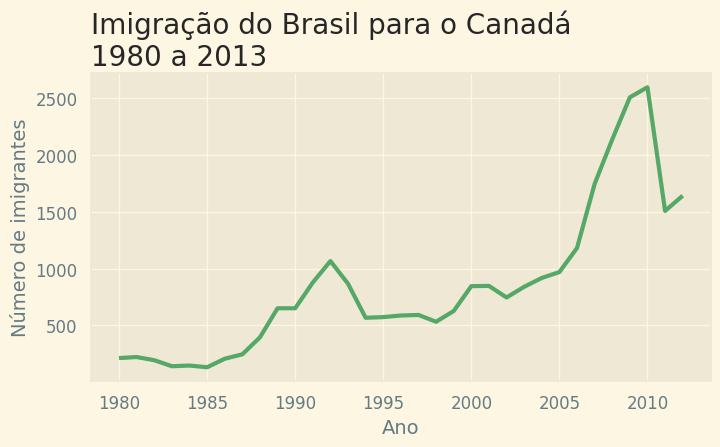

In [ ]:
with plt.style.context('Solarize_Light2'):
  fig, ax = plt.subplots(figsize=(8, 4))
  ax.plot(dados_brasil['ano'], dados_brasil['imigrantes'], lw=3, color='g')
  ax.set_title('Imigração do Brasil para o Canadá\n1980 a 2013', fontsize=20, loc='left')
  ax.set_ylabel('Número de imigrantes', fontsize=14)
  ax.set_xlabel('Ano', fontsize=14)
  ax.yaxis.set_tick_params(labelsize=12)
  ax.xaxis.set_tick_params(labelsize=12)
  ax.xaxis.set_major_locator(plt.MultipleLocator(5))
  plt.show()

In [ ]:
america_sul = df.query('Região == "América do Sul"')
america_sul.sort_values('Total', ascending=True, inplace=True)

/tmp/ipykernel_3982/1702940669.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



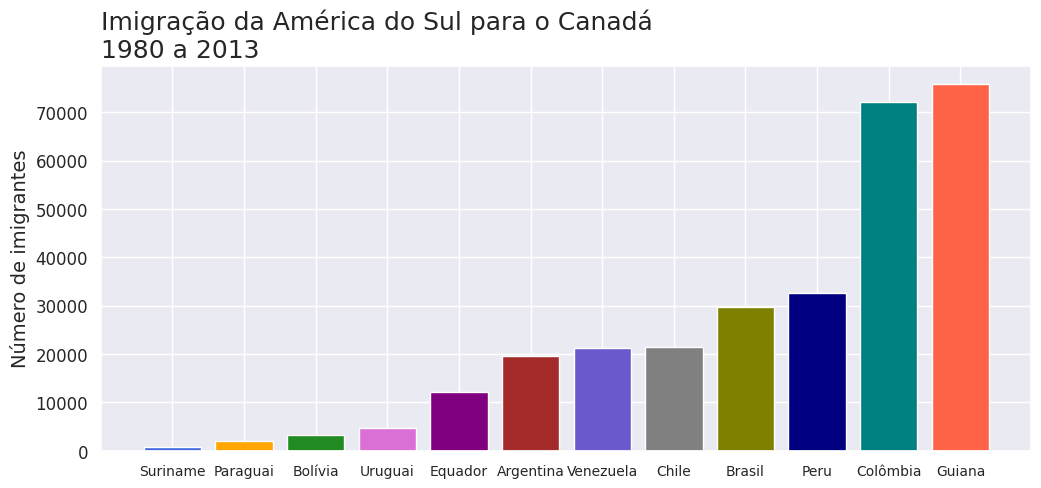

In [ ]:
cores = ['royalblue', 'orange', 'forestgreen', 'orchid', 'purple', 'brown', 'slateblue', 'gray', 'olive', 'navy', 'teal', 'tomato']

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(america_sul.index, america_sul['Total'], color=cores)
ax.set_title('Imigração da América do Sul para o Canadá\n1980 a 2013', loc='left', fontsize=18)
ax.set_ylabel('Número de imigrantes', fontsize=14)
ax.set_xlabel('')
ax.yaxis.set_tick_params(labelsize=12)
ax.xaxis.set_tick_params(labelsize=10)

plt.show()

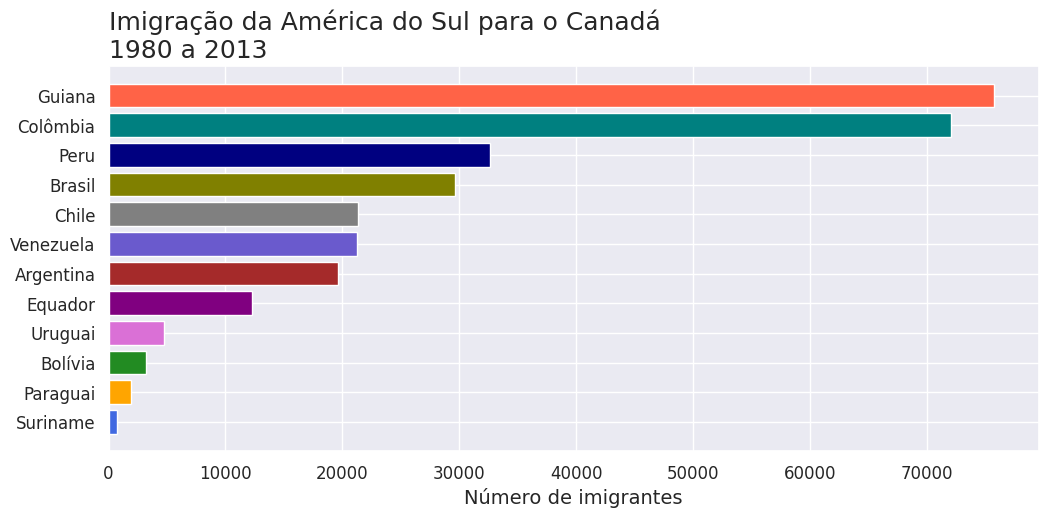

In [ ]:
cores = ['royalblue', 'orange', 'forestgreen', 'orchid', 'purple', 'brown', 'slateblue', 'gray', 'olive', 'navy', 'teal', 'tomato']

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(america_sul.index, america_sul['Total'], color=cores)
ax.set_title('Imigração da América do Sul para o Canadá\n1980 a 2013', loc='left', fontsize=18)
ax.set_xlabel('Número de imigrantes', fontsize=14)
ax.set_ylabel('')
ax.yaxis.set_tick_params(labelsize=12)
ax.xaxis.set_tick_params(labelsize=12)

plt.show()

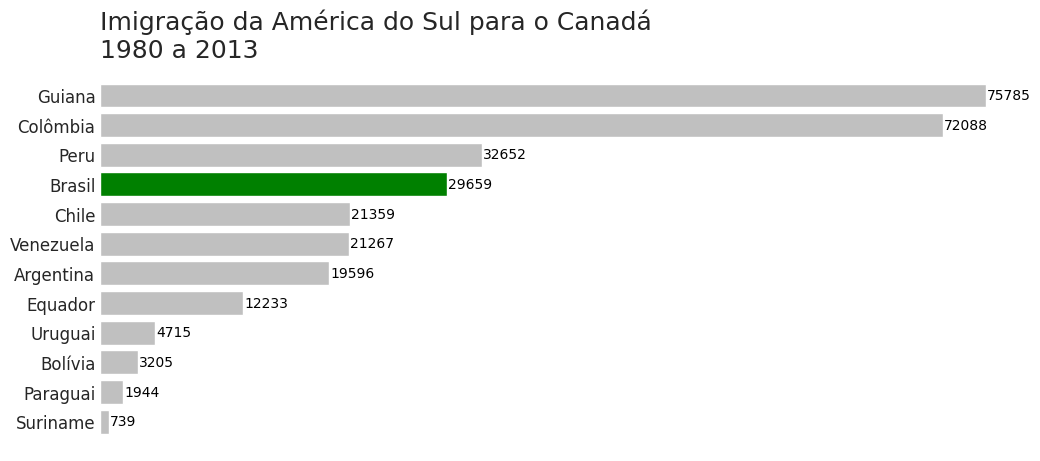

In [ ]:
cores = []
for pais in america_sul.index:
  if pais == 'Brasil':
    cores.append('green')
  else:
    cores.append('silver')

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(america_sul.index, america_sul['Total'], color=cores)
ax.set_title('Imigração da América do Sul para o Canadá\n1980 a 2013', loc='left', fontsize=18)
ax.set_xlabel('Número de imigrantes', fontsize=14)
ax.set_ylabel('')
ax.yaxis.set_tick_params(labelsize=12)
ax.xaxis.set_tick_params(labelsize=12)

for i, v in enumerate(america_sul['Total']):
  ax.text(v + 100, i, str(v), color='black', fontsize=10, ha='left', va='center')

ax.set_frame_on(False)
ax.get_xaxis().set_visible(False)
ax.tick_params(axis='both', which='both', length=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig("Imigracao_brasil_canada.png", dpi=300, transparent=False, bbox_inches='tight')
plt.show()

In [ ]:
print(fig.canvas.get_supported_filetypes())

{'eps': 'Encapsulated Postscript', 'jpg': 'Joint Photographic Experts Group', 'jpeg': 'Joint Photographic Experts Group', 'pdf': 'Portable Document Format', 'pgf': 'PGF code for LaTeX', 'png': 'Portable Network Graphics', 'ps': 'Postscript', 'raw': 'Raw RGBA bitmap', 'rgba': 'Raw RGBA bitmap', 'svg': 'Scalable Vector Graphics', 'svgz': 'Scalable Vector Graphics', 'tif': 'Tagged Image File Format', 'tiff': 'Tagged Image File Format', 'webp': 'WebP Image Format'}


In [ ]:
lojas = ['A', 'B', 'C', 'D']

vendas_2022 = {'Jan': [100, 80, 150, 50],
    'Fev': [120, 90, 170, 60],
    'Mar': [150, 100, 200, 80],
    'Abr': [180, 110, 230, 90],
    'Mai': [220, 190, 350, 200],
    'Jun': [230, 150, 280, 120],
    'Jul': [250, 170, 300, 140],
    'Ago': [260, 180, 310, 150],
    'Set': [240, 160, 290, 130],
    'Out': [220, 140, 270, 110],
    'Nov': [400, 220, 350, 190],
    'Dez': [300, 350, 400, 250]
}

# Criando DataFrame
lojas = pd.DataFrame(vendas_2022, index=lojas)

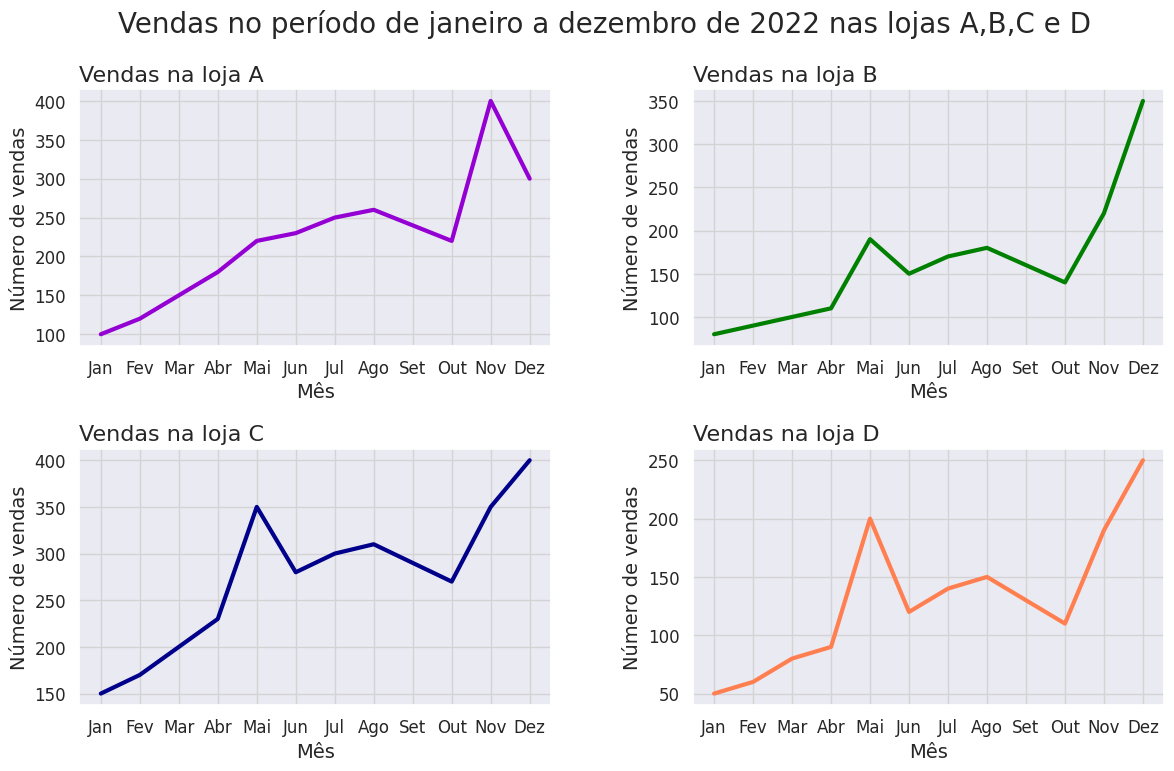

In [ ]:
# Criar a figura e os subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# Ajustar os espaçamentos entre os subplots
plt.subplots_adjust(wspace=0.3, hspace=0.4)

# Adicionando um título geral para os subplots
fig.suptitle('Vendas no período de janeiro a dezembro de 2022 nas lojas A,B,C e D', fontsize=20)

# Lista de cores
cores = ['darkviolet', 'green', 'darkblue', 'coral']

#Loop para plotar e customizar os subplots
for i, ax in enumerate(axs.flat):
    ax.plot(lojas.loc[lojas.index[i]], color=cores[i], lw=3)
    ax.set_title(f'Vendas na loja {lojas.index[i]}', loc='left', fontsize=16)
    ax.set_xlabel('Mês', fontsize=14)
    ax.set_ylabel('Número de vendas', fontsize=14)
    ax.tick_params(labelsize=12)
    ax.grid(color='lightgrey')

SEABORN - SNS

In [ ]:
sns.set_theme(style='dark', palette='deep', font='serif', context='notebook')

In [ ]:
top10 = df.sort_values('Total', ascending=False).head(10).reset_index()

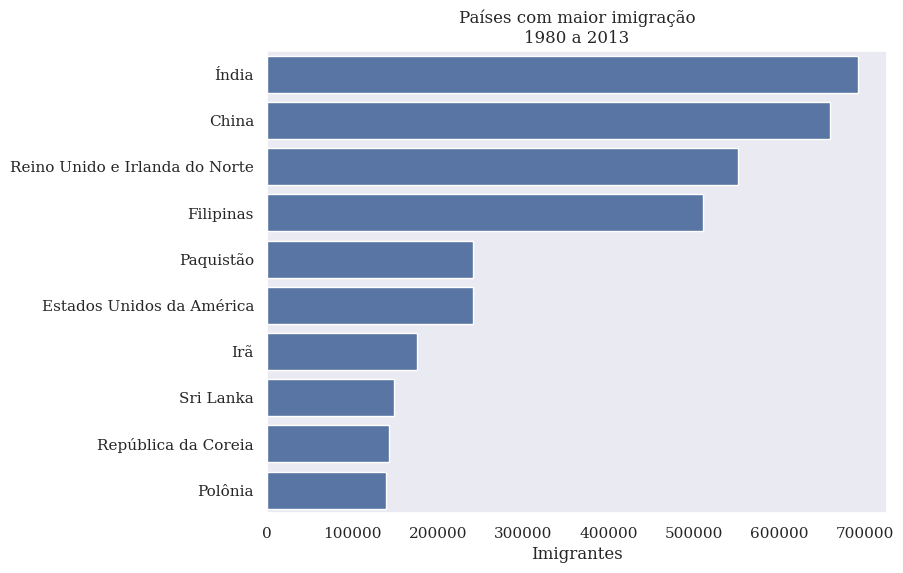

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax = sns.barplot(data=top10, y='País', x='Total', orient='h')
ax.set(title="Países com maior imigração\n1980 a 2013",
       xlabel = 'Imigrantes',
       ylabel = '')

plt.show()

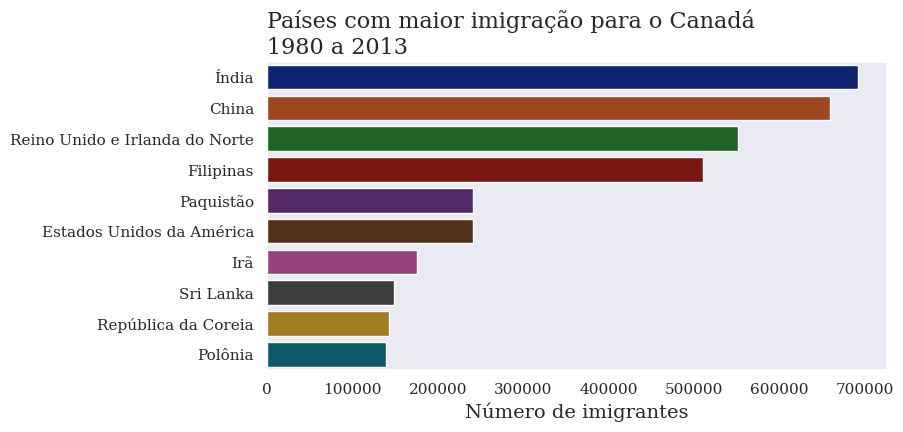

In [ ]:
def gerar_grafico_paleta(palette):
  fig, ax = plt.subplots(figsize=(8, 4))
  ax = sns.barplot(data=top10, y='País', x='Total', hue='País', orient='h', palette=palette)
  ax.set_title('Países com maior imigração para o Canadá\n1980 a 2013', loc='left', fontsize=16)
  ax.set_xlabel('Número de imigrantes', fontsize=14)
  ax.set_ylabel('', fontsize=14)
  plt.show()

gerar_grafico_paleta('dark')

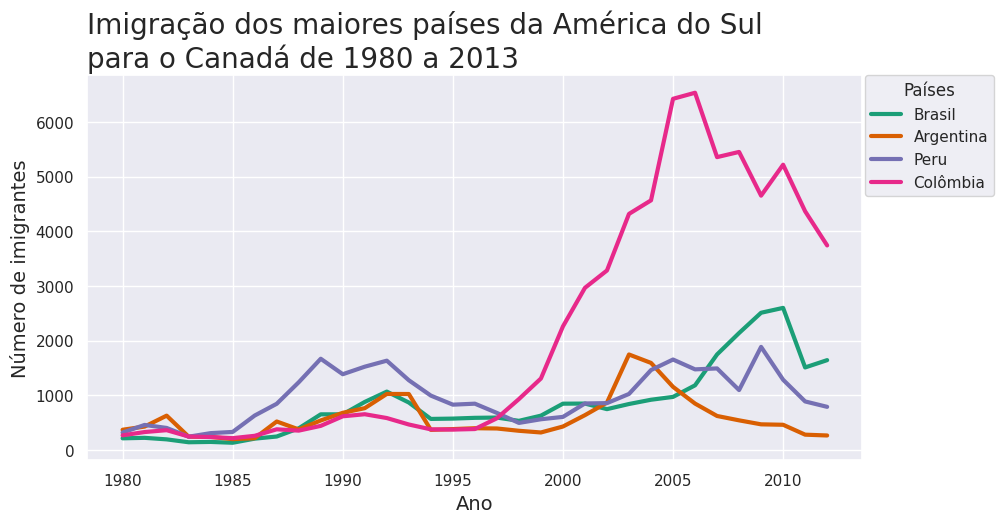

In [ ]:
sns.set_theme()
sns.set_palette('Dark2')

fig, ax = plt.subplots(figsize=(10, 5))
ax = sns.lineplot(df.loc['Brasil', anos], label='Brasil', lw=3)
ax = sns.lineplot(df.loc['Argentina', anos], label='Argentina', lw=3)
ax = sns.lineplot(df.loc['Peru', anos], label='Peru', lw=3)
ax = sns.lineplot(df.loc['Colômbia', anos], label='Colômbia', lw=3)

ax.set_title('Imigração dos maiores países da América do Sul\npara o Canadá de 1980 a 2013', loc='left', fontsize=20)
ax.set_xlabel('Ano', fontsize=14)
ax.set_ylabel('Número de imigrantes', fontsize=14)

ax.xaxis.set_major_locator(plt.MultipleLocator(5))

ax.legend(title='Países', loc='upper right', bbox_to_anchor=(1.18, 1.02))

plt.show()

PLOTLY

In [ ]:
import plotly.express as px

fig = px.line(dados_brasil,
              x='ano',
              y='imigrantes',
              title='Imigração do Brasil para o Canadá de 1980 a 2013')
fig.update_layout(
    xaxis_title='Ano',
    yaxis_title='Número de imigrantes',
    width = 1000,
    height = 500,
    xaxis={'tickangle':-45},
    font_family='Arial',
    font_size=14,
    font_color='grey',
    title_font_size=22)
fig.update
fig.show()

In [ ]:
america_sul.head()

,Continente,Região,1980,1981,1982,1983,1984,1985,1986,1987,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
País,,,,,,,,,,,,,,,,,,,,,
Suriname,América Latina e o Caribe,América do Sul,15,10,21,12,5,16,7,46,...,15,16,20,9,12,13,11,16,4,739
Paraguai,América Latina e o Caribe,América do Sul,45,26,32,40,48,36,34,72,...,75,88,98,95,88,89,83,55,66,1944
Bolívia,América Latina e o Caribe,América do Sul,44,52,42,49,38,44,79,165,...,134,139,107,143,214,180,86,83,107,3205
Uruguai,América Latina e o Caribe,América do Sul,128,132,146,105,90,92,137,269,...,217,175,147,160,99,93,81,47,58,4715
Equador,América Latina e o Caribe,América do Sul,238,207,184,155,179,208,240,344,...,491,525,419,437,373,353,348,282,418,12233


In [ ]:
america_sul = df.query('Continente == "América Latina e o Caribe"')
america_sul.loc[america_sul.index, anos]
america_sul.drop(['Continente', 'Região', 'Total'], axis=1, inplace=True)
america_sul = america_sul.T
america_sul.head()

/tmp/ipykernel_3982/411139823.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



País,Antígua e Barbuda,Argentina,Bahamas,Barbados,Belize,Bolívia,Brasil,Chile,Colômbia,Costa Rica,...,Panamá,Paraguai,Peru,Saint Kitts e Nevis,Santa Lúcia,São Vicente e Granadinas,Suriname,Trinidad e Tobago,Uruguai,Venezuela
1980,0,368,26,372,16,44,211,1233,266,28,...,13,45,317,5,69,147,15,958,128,103
1981,0,426,23,376,27,52,220,1069,326,35,...,8,26,456,3,89,190,10,947,132,117
1982,0,626,38,299,13,42,192,1078,360,42,...,14,32,401,0,133,202,21,972,146,174
1983,0,241,12,244,21,49,139,781,244,51,...,10,40,241,16,69,154,12,766,105,124
1984,42,237,21,265,37,38,145,681,235,75,...,11,48,306,21,68,158,5,606,90,142


In [ ]:
fig = px.line(america_sul,
              x=america_sul.index,
              y=america_sul.columns,
              color='País',
              title='Imigração do Brasil para o Canadá de 1980 a 2013')
fig.update_layout(
    xaxis_title='Ano',
    yaxis_title='Número de imigrantes',
    width = 1000,
    height = 500,
    xaxis={'tickangle':-45},
    font_family='Arial',
    font_size=14,
    font_color='grey',
    title_font_size=22)
fig.update
fig.show()

In [ ]:
fig.write_html('imigracao_america_sul.html')

In [ ]:
dados_brasil['ano'] = dados_brasil['ano'].astype(int)

import plotly.graph_objs as go

# Criando uma figura
fig = go.Figure()

# Adicionando a linha do gráfico e definindo a espessura da linha
fig.add_trace(
    go.Scatter(x=[dados_brasil['ano'].iloc[0]], y=[dados_brasil['imigrantes'].iloc[0]], mode='lines', name='Imigrantes', line=dict(width=4))
)

# Definindo as configurações de layout
fig.update_layout(
    title=dict(
        text='<b>Imigração do Brasil para o Canadá no período de 1980 a 2013</b>',
        x=0.12,
        xanchor='left',
        font=dict(size=20)
    ),
    xaxis=dict(range=[1980, 2013], autorange=False, title='<b>Ano</b>'),
    yaxis=dict(range=[0, 3000], autorange=False, title='<b>Número de imigrantes</b>'),
    updatemenus=[dict(

        type='buttons',

        showactive=False,

        buttons=[dict(

            label='Play',

            method='animate',

            args=[None, {'frame': {'duration': 100, 'redraw': True}, 'fromcurrent': True}]
        )]
    )],
    width=1000,
    height=500
)

# Definir as configurações de animação
frames = [go.Frame(data=[go.Scatter(x=dados_brasil['ano'].iloc[:i+1], y=dados_brasil['imigrantes'].iloc[:i+1])]) for i in range(len(dados_brasil))]
fig.frames = frames

# Mostrando a figura
fig.show()